# TP7 – CNN
### Sharaine MALARVIJY 21206543

In [111]:
from TP7_ETU import *

## I - Load pre-shuffled MNIST data train and test sets

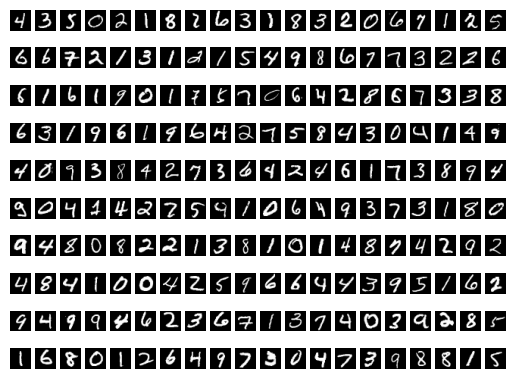

In [112]:
# load dataset
(X_train, y_train), (X_test, y_test) = load_data()

np.random.seed(123)  # for reproducibility
n_etu = 543

# Ne conserve que 10% de la base
X_train, pipo, y_train, pipo = train_test_split(
    X_train, y_train, test_size=0.9, random_state=n_etu
)
X_test, pipo, y_test, pipo = train_test_split(
    X_test, y_test, test_size=0.9, random_state=n_etu
)

# affichage des quelques image de la base d'apprentissage
for i in range(200):
    plt.subplot(10, 20, i + 1)
    plt.imshow(X_train[i, :].reshape([28, 28]), cmap="gray")
    plt.axis("off")
plt.show()

# Preprocess input data
# On rajoute une dimention dans X_train et X_test car on a qu'un canal d'image noir et blanc pour le CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_train.shape[1], X_train.shape[2], 1)
# transforme les données en float32 de 0 à 1
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
# puis on normalise les données
X_train /= 255
X_test /= 255


# Preprocess class labels
# Fait une matrice binaire par classes (One Hot Encoding) sur train et test.
# C'est nécessaire pour la fonction de loss categorical_crossentropy
Y_train = tf.keras.utils.to_categorical(y_train, 10)
Y_test = tf.keras.utils.to_categorical(y_test, 10)

In [113]:
print(f"La dimension des données sont de {X_train.shape} pour la base d’apprentissage")
print(f"La dimension des données sont de {X_test.shape} pour la base de test")

print(f"Il y a {X_train.shape[0]} images dans la base d’apprentissage")
print(f"Il y a {X_test.shape[0]} images dans la base de test")
print(f"Les images sont de dimension {X_train.shape[1]}x{X_train.shape[2]} pixels")
nb_classe = round(max(y_test) + 1)
print(f"Il y a {nb_classe} classes")

print(f"La dimension de Y_train sont de {Y_train.shape}")
print(f"La dimension de Y_test sont de {Y_test.shape}")

La dimension des données sont de (6000, 28, 28, 1) pour la base d’apprentissage
La dimension des données sont de (1000, 28, 28, 1) pour la base de test
Il y a 6000 images dans la base d’apprentissage
Il y a 1000 images dans la base de test
Les images sont de dimension 28x28 pixels
Il y a 10 classes
La dimension de Y_train sont de (6000, 10)
La dimension de Y_test sont de (1000, 10)


Le pré-traitement des données reduit les données pour le temps de calcul et permet qu'elle soit utiliser par tensorflow.

La fonction tf.keras.utils.to_categorical sert a faire un One Hot Encoding. C'est nécessaire pour la fonction de loss categorical_crossentropy

## II - Régression logistique
### II.1. Define model architecture

In [114]:
# Define model architecture
inputs = Input(shape=(28, 28, 1))
x = inputs
x = Flatten()(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

print("Nombre de paramètre calculer à la main :", 10 * (28 * 28 + 1))

Model: "functional_73"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_73 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_73 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Nombre de paramètre calculer à la main : 7850


Une fonction d’activation softmax transforme la sortie du réseau en probabilités d’appartenance aux classes.
La commande flatten aplatit les données en une dimension.

## II.2. Apprentissage

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1685 - loss: 2.2684 - val_accuracy: 0.2810 - val_loss: 2.1155
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3552 - loss: 2.0290 - val_accuracy: 0.4520 - val_loss: 1.9074
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5053 - loss: 1.8414 - val_accuracy: 0.5900 - val_loss: 1.7383
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6152 - loss: 1.6861 - val_accuracy: 0.6720 - val_loss: 1.5975
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6808 - loss: 1.5557 - val_accuracy: 0.7250 - val_loss: 1.4794
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7185 - loss: 1.4461 - val_accuracy: 0.7570 - val_loss: 1.3802
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7432 - loss: 1.3535 - val_accuracy: 0.7730 - val_loss: 1.2962
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7603 - loss: 1.2747 - val_accuracy: 0.7820 - val_loss:

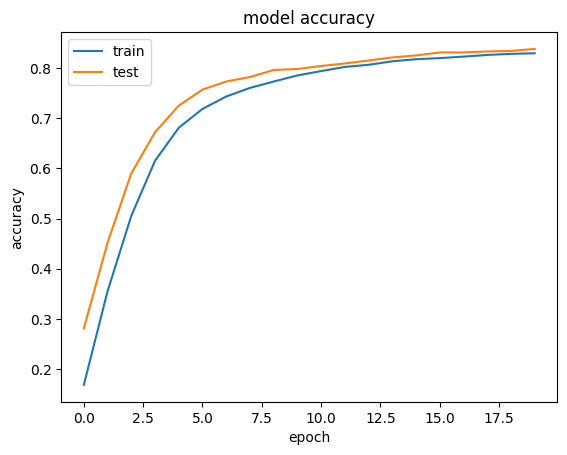

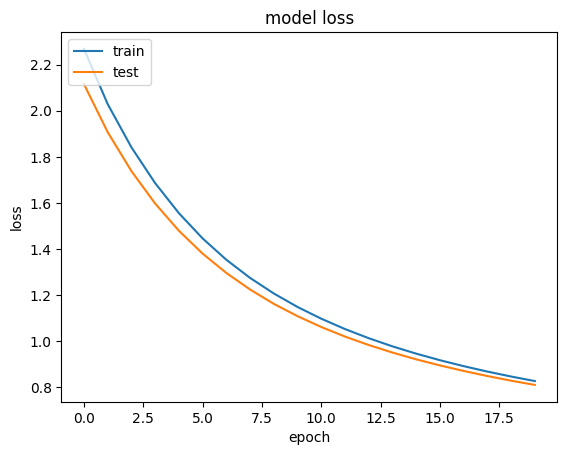

lr= 0.01 batch_size= 256 epochs= 20
Temps d'apprentissage : 2.507s


In [115]:
lr = 0.01
batch_size = 256
epochs = 20
# On defini l'optimiseur SGD avec un lr de depart
sgd1 = tf.keras.optimizers.SGD(learning_rate=lr)

# On defini la fonction de perte
model.compile(loss="categorical_crossentropy", optimizer=sgd1, metrics=["accuracy"])
tps1 = time.time()

history = model.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, Y_test),
)
tps2 = time.time()

affiche(history)
print("lr=", lr, "batch_size=", batch_size, "epochs=", epochs)
print(f"Temps d'apprentissage : {round((tps2 - tps1), 3)}s")

lr (learning rate) represente le pas d’apprentissage 

batch : sous ensemble de la base d’apprentissage

epoch : nombre de fois que tous les exemples sont vus en apprentissage

La 'categorical_crossentropy’ est efficace pour la classification multi-classes.
La fonction de perte utilisée est donc la categorical cross entropy.

La fonction affiche(history) affiche l'accuracy et la loss en fonction de l'epoch.
L'appentissage se passe bien mais le lr est un peu bas pour ce nombre d'epoch.

## II.3. Evaluation du modèle

In [116]:
score = model.evaluate(X_test, Y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=-1)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Test loss: 0.810314953327179
Test accuracy: 0.8379999995231628
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Confusion Matrix
[[104   0   1   0   0   2   1   0   1   0]
 [  0 101   1   1   0   0   1   0   4   0]
 [  1   5  74   1   4   0   4   2   3   2]
 [  1   1   1  82   0   3   2   2   6   4]
 [  0   0   0   0  88   0   5   0   0   6]
 [  3   3   0   9   3  58   3   1   5   1]
 [  1   0   1   0   3   1  86   0   0   0]
 [  1   5   3   0   1   0   1  81   1   3]
 [  1   4   1   9   1   2   1   2  79   1]
 [  1   1   1   3  10   1   0   9   0  85]]


model.predict renvoi une liste par classe, chaque liste a 1000 element qui représente la probabilité d'appartenance de l'image de test à la classe de la liste. y_pred.argmax permet d'avoir la classe predite par image

Epoch 1/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6867 - loss: 1.2826 - val_accuracy: 0.8360 - val_loss: 0.8039
Epoch 2/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8412 - loss: 0.7013 - val_accuracy: 0.8640 - val_loss: 0.6200
Epoch 3/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8637 - loss: 0.5727 - val_accuracy: 0.8690 - val_loss: 0.5443
Epoch 4/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8752 - loss: 0.5107 - val_accuracy: 0.8800 - val_loss: 0.4942
Epoch 5/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8817 - loss: 0.4714 - val_accuracy: 0.8850 - val_loss: 0.4688
Epoch 6/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8868 - loss: 0.4448 - val_accuracy: 0.8850 - val_loss: 0.4491
Epoch 7/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8927 - loss: 0.4232 - val_accuracy: 0.8860 - val_loss: 0.4341
Epoch 8/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8940 - loss: 0.4075 - val_accuracy: 0.8870 - val_loss:

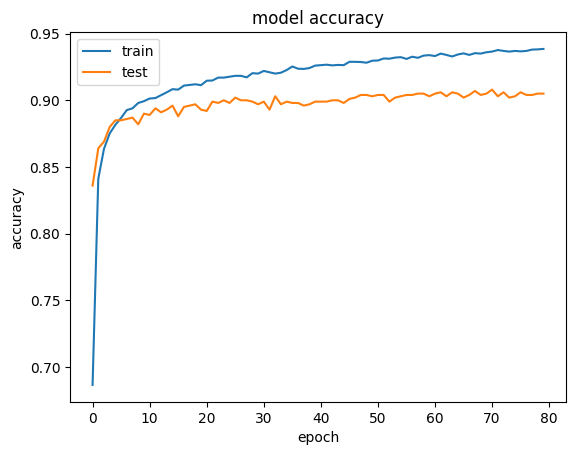

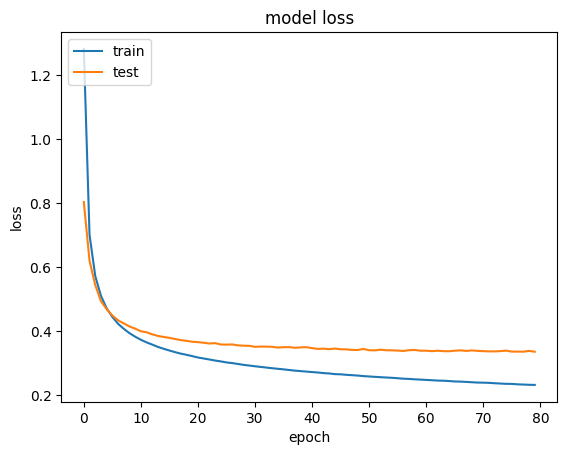

lr= 0.2 batch_size= 256 epochs= 80
train_accuracy= 93.83 test_accuracy= 90.5
Temps d apprentissage : 8.711s


In [117]:
lr = 0.2
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = inputs
x = Flatten()(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)

sgd1 = tf.keras.optimizers.SGD(learning_rate=lr)

model.compile(loss="categorical_crossentropy", optimizer=sgd1, metrics=["accuracy"])
tps1 = time.time()


history = model.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, Y_test),
)
tps2 = time.time()

affiche(history)
train_accuracy = np.mean(history.history["accuracy"][-2:])
test_accuracy = np.mean(history.history["val_accuracy"][-2:])

print("lr=", lr, "batch_size=", batch_size, "epochs=", epochs)
print(
    "train_accuracy=",
    round(train_accuracy * 100, 2),
    "test_accuracy=",
    round(test_accuracy * 100, 2),
)
print(f"Temps d apprentissage : {round((tps2 - tps1), 3)}s")

J'arrive a obtenir un taux de reconnaissance de ~90% en me limitant a un temps de calcul de ~9s 

## III. MLP

In [118]:
print("Nombre de paramètre à estimer calculer à la main :", 256 * (28 * 28 + 1))

Nombre de paramètre à estimer calculer à la main : 200960


### 1 Couche cachée

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_75 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_75 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

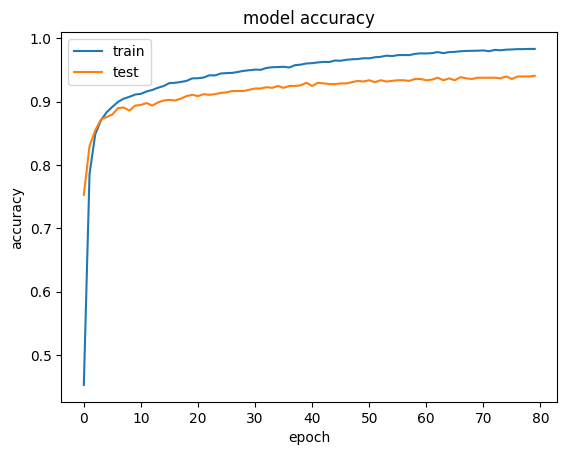

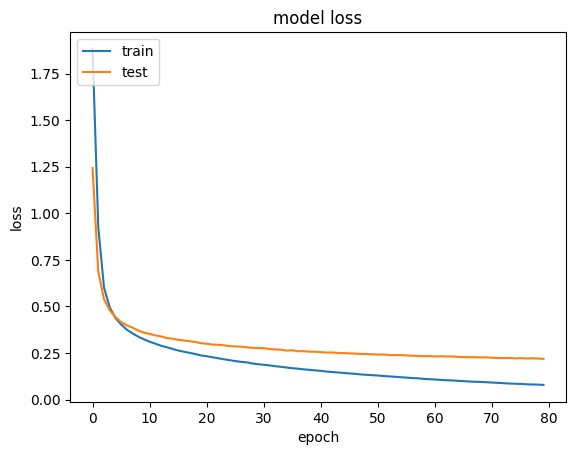

lr= 0.01 momentum= 0.9 batch_size= 256 epochs= 80
train_accuracy= 98.35 test_accuracy= 94.1
Temps d apprentissage : 11.04s


In [119]:
lr = 0.01
momentum = 0.9
batch_size = 256
epochs = 80

# Define model architecture
inputs = Input(shape=(28, 28, 1))

x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()


def train(model, lr, momentum, batch_size, epochs, verbose=0):
    sgd1 = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)

    model.compile(loss="categorical_crossentropy", optimizer=sgd1, metrics=["accuracy"])
    tps1 = time.time()

    history = model.fit(
        X_train,
        Y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=verbose,
        validation_data=(X_test, Y_test),
    )
    tps2 = time.time()

    affiche(history)
    train_accuracy = history.history["accuracy"][-1]
    test_accuracy = history.history["val_accuracy"][-1]
    print(
        "lr=", lr, "momentum=", momentum, "batch_size=", batch_size, "epochs=", epochs
    )
    print(
        "train_accuracy=",
        round(train_accuracy * 100, 2),
        "test_accuracy=",
        round(test_accuracy * 100, 2),
    )
    print(f"Temps d apprentissage : {round((tps2 - tps1), 3)}s")


train(model, lr, momentum, batch_size, epochs)

### lr trop grand 

Model: "functional_76"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_76 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_76 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_140 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_141 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

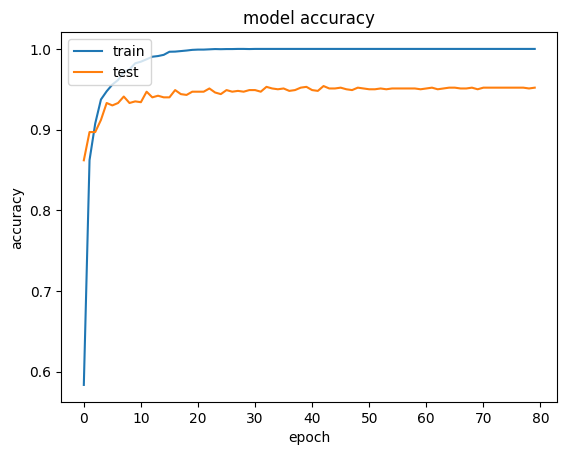

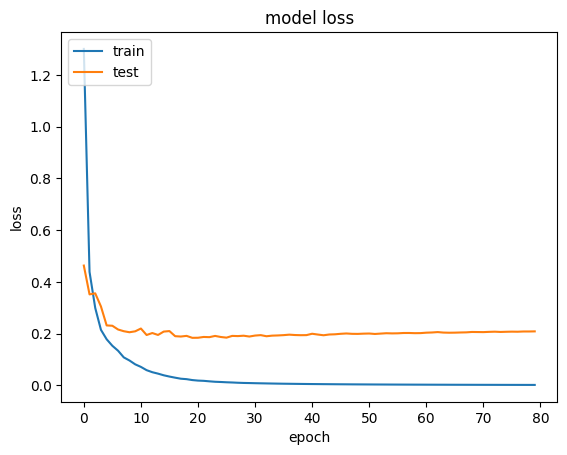

lr= 0.9 momentum= 0.0 batch_size= 256 epochs= 80
train_accuracy= 100.0 test_accuracy= 95.2
Temps d apprentissage : 11.001s


In [120]:
lr = 0.9
momentum = 0.0
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

### lr trop petit

Model: "functional_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_77 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_77 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_142 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_143 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

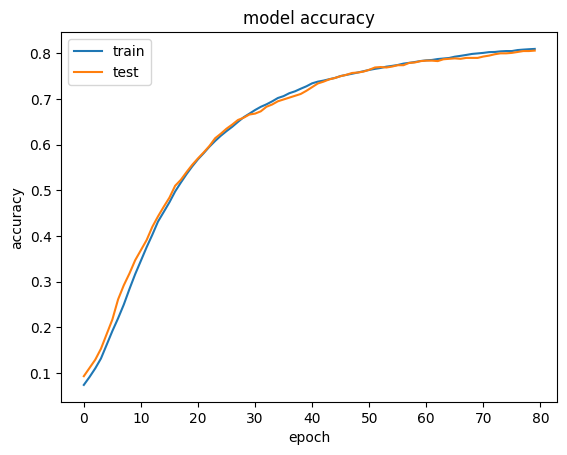

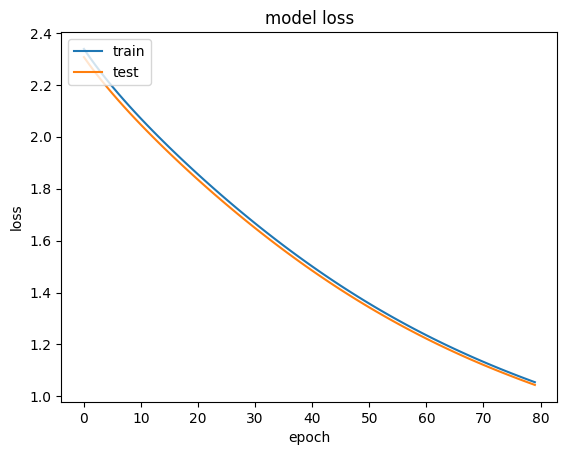

lr= 0.001 momentum= 0.0 batch_size= 256 epochs= 80
train_accuracy= 80.97 test_accuracy= 80.6
Temps d apprentissage : 10.745s


In [121]:
lr = 0.001
momentum = 0.0
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

### Effet du momentum avec un lr petit

Model: "functional_78"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_78 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_78 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_144 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_145 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

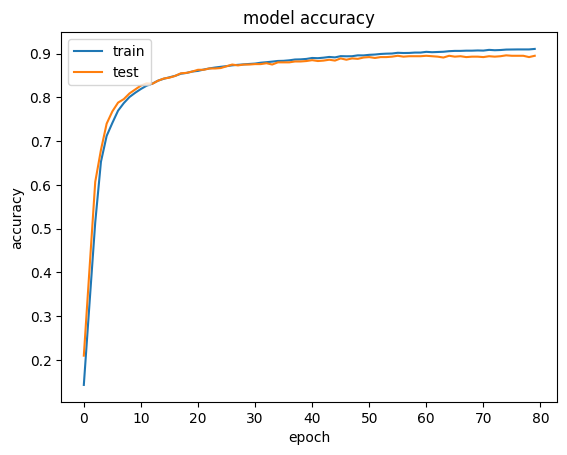

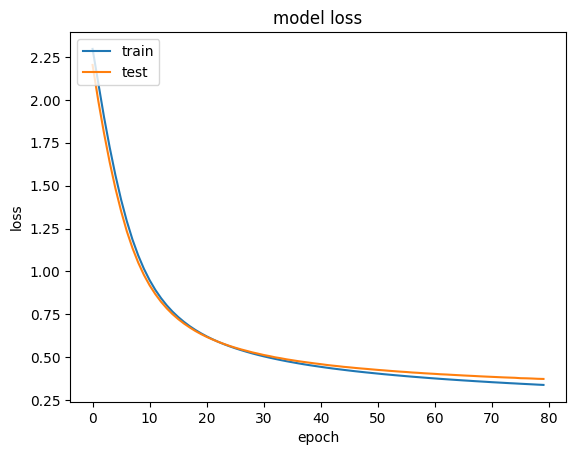

lr= 0.001 momentum= 0.9 batch_size= 256 epochs= 80
train_accuracy= 91.07 test_accuracy= 89.5
Temps d apprentissage : 11.019s


In [122]:
lr = 0.001
momentum = 0.9
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

Model: "functional_79"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_79 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_79 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_146 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

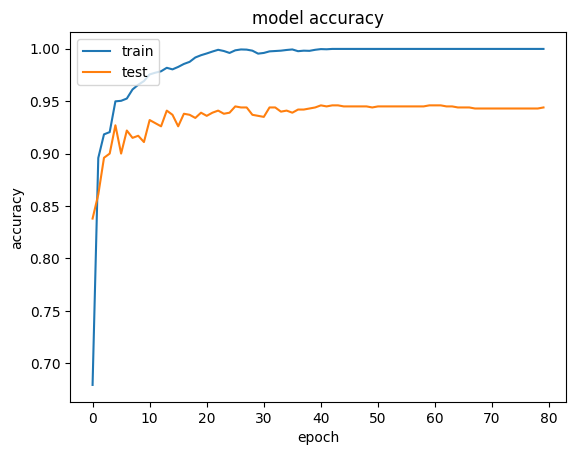

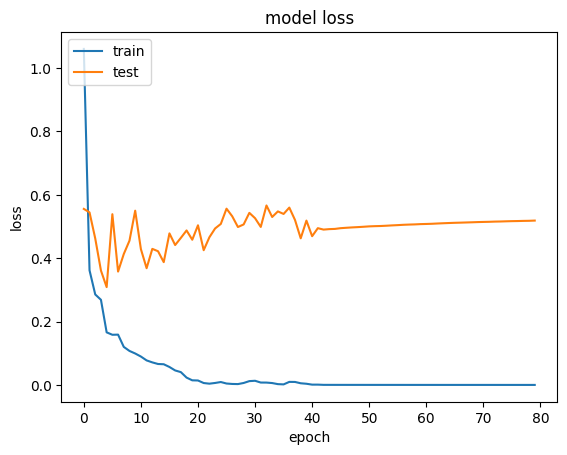

lr= 0.9 momentum= 0.9 batch_size= 256 epochs= 80
train_accuracy= 99.98 test_accuracy= 94.4
Temps d apprentissage : 11.484s


In [123]:
lr = 0.9
momentum = 0.9
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

Le momentum a permit d'accelerer la SGD quand le lr était petit et n'a pas d'effet si le lr est trop grand.

### 1 Couche cachée et 1 dropout

Model: "functional_80"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_80 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_80 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

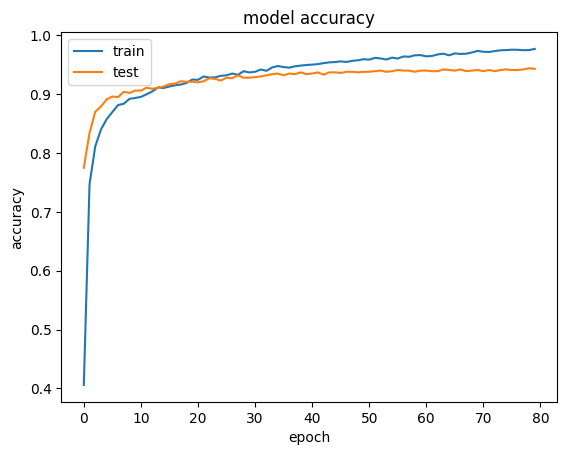

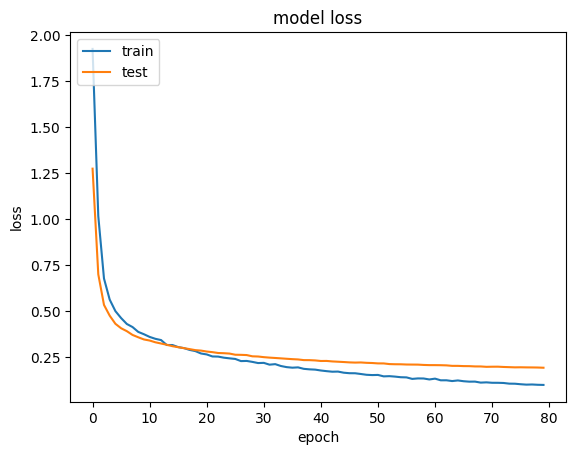

lr= 0.01 momentum= 0.9 batch_size= 256 epochs= 80
train_accuracy= 97.68 test_accuracy= 94.3
Temps d apprentissage : 12.23s


In [124]:
lr = 0.01
momentum = 0.9
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

Le dropout permet de reduire le sur-apprentissage.

### 2 Couche cachées et 1 dropout

Model: "functional_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_81 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_81 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_151 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

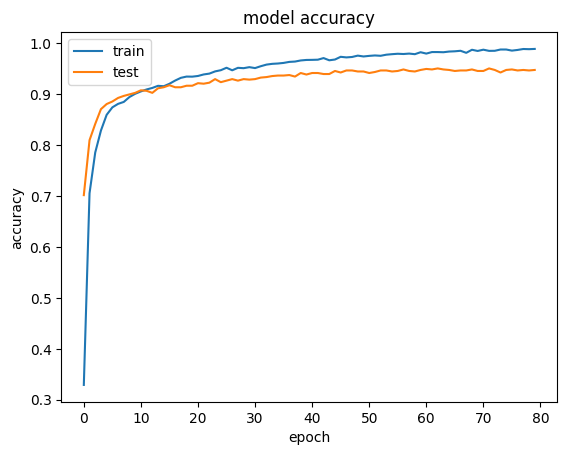

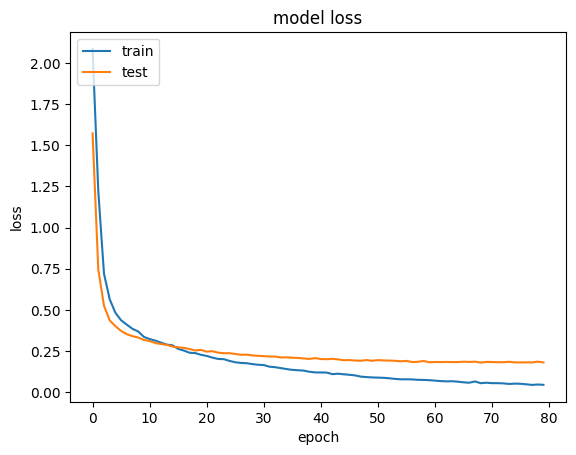

lr= 0.01 momentum= 0.9 batch_size= 256 epochs= 80
train_accuracy= 98.93 test_accuracy= 94.8
Temps d apprentissage : 13.474s


In [125]:
lr = 0.01
momentum = 0.9
batch_size = 256
epochs = 80

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

En ajoutant une couche cachée on a augmenter l'accuracy et le temps de calcul.

Conclusion : 
Avec du momentum on peut reduire le lr sans avoir a augmente le nombre d'epoch et en ajoutant du dropout on reduit le sur-apprentissage.

## IV. CNN

In [126]:
print("Nombre de paramètre calculer à la main")
print("Couche 1", 32 * (3 * 3 + 1))
print("Couche 2", 64 * (3 * 3 * 32 + 1))

Nombre de paramètre calculer à la main
Couche 1 320
Couche 2 18496


### Point de comparaison avec 15 epochs

Model: "functional_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_82 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_82 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

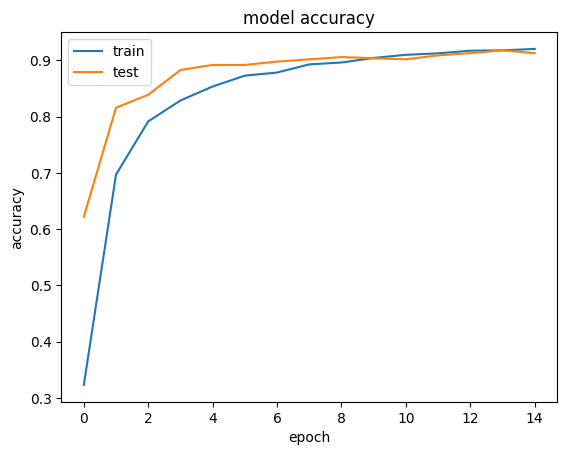

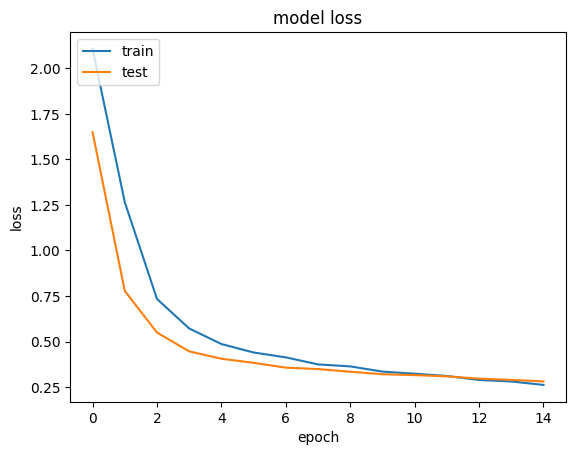

lr= 0.01 momentum= 0.9 batch_size= 256 epochs= 15
train_accuracy= 92.05 test_accuracy= 91.3
Temps d apprentissage : 3.046s


In [127]:
lr = 0.01
momentum = 0.9
batch_size = 256
epochs = 15

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

Model: "functional_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_83 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_83 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_156 (Dense)               │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_157 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_158 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,932,490 (49.33 MB)

 Trainable params: 12,932,490 (49.33 MB)

 Non-trainable params: 0 (0.00 B)

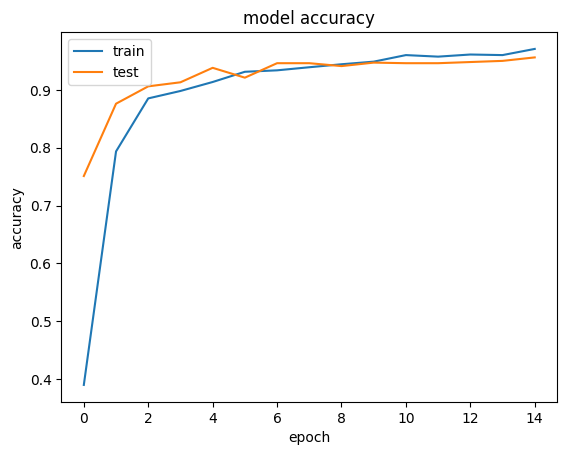

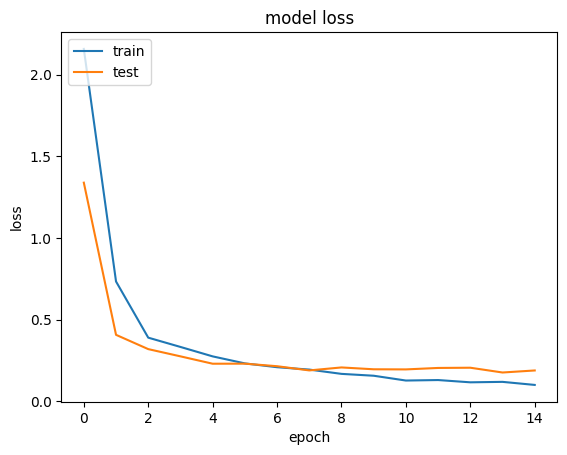

lr= 0.01 momentum= 0.9 batch_size= 256 epochs= 15
train_accuracy= 97.07 test_accuracy= 95.6
Temps d apprentissage : 92.565s


In [128]:
lr = 0.01
momentum = 0.9
batch_size = 256
epochs = 15

inputs = Input(shape=(28, 28, 1))
x = inputs
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()


train(model, lr, momentum, batch_size, epochs)

Le temps de calcul est beaucoup plus lent avec une convergence legèrement plus rapide.

Model: "functional_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_84 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_84 (Flatten)            │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_160 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_161 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,298,698 (12.58 MB)

 Trainable params: 3,298,698 (12.58 MB)

 Non-trainable params: 0 (0.00 B)

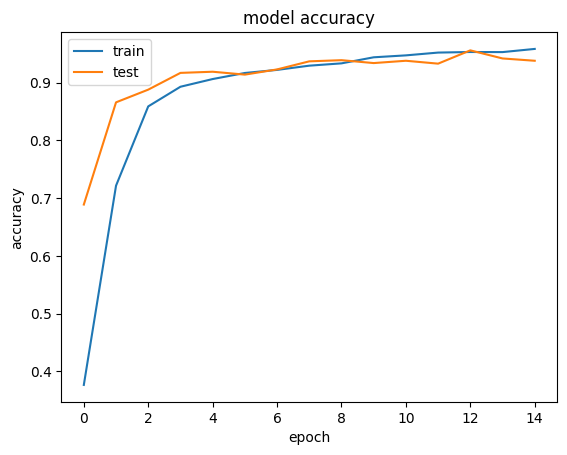

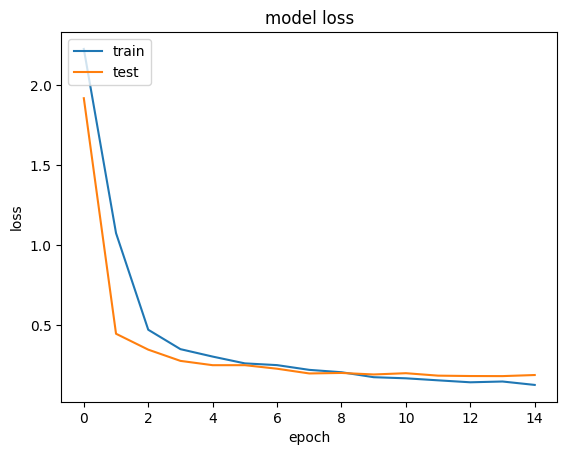

lr= 0.01 momentum= 0.9 batch_size= 256 epochs= 15
train_accuracy= 95.85 test_accuracy= 93.8
Temps d apprentissage : 72.116s


In [ ]:
lr = 0.01
momentum = 0.9
batch_size = 256
epochs = 15

inputs = Input(shape=(28, 28, 1))
x = inputs
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
outputs = Dense(10, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

train(model, lr, momentum, batch_size, epochs)

Avec le maxpooling on a un resultat un peu moins bon mais on a réduit le temps de calcul car on reduit le nombre de paramètre. 

Sur ces images il n'y a pas de grand intérêt à utiliser un CNN car on est sur des images de faible dimention et les images sont simple il n'y a pas de textures complexes ou de variations importantes.

La force du CNN va être son efficacité pour reconnaitre les formes complexes, son invariances en translation et son temps de calcul sur les grandes images.